In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from astropy.table import Table, join
import tqdm

In [2]:
# data
nsa = Table.read('/pscratch/sd/n/nravi/GV_classification/nsa_v1_0_1_cd.fits', format='fits')
nsa[0:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0,15.35612518948784,1.0107145649262792,0.4432756950779825,1.4675833040303574,14.144876756638748,1.4847430549483402,0.314021764798245,1.1390655081408774,-0.2209

In [3]:
kias = Table.read('/pscratch/sd/n/nravi/GV_classification/NSA_v1_0_1_vflag_Portsmouth.fits')
kias[0:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

## check cd distribution

Text(0.5, 0, '$\\Delta (g-i)$')

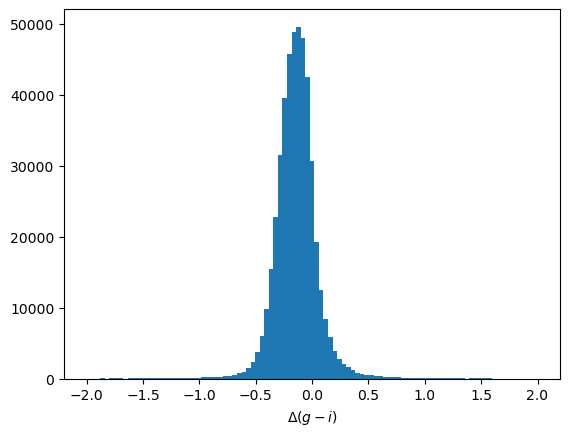

In [4]:
plt.hist(nsa['NSA_cd'], bins=np.linspace(-2,2,100))
plt.xlabel(r'$\Delta (g-i)$')

## calculate $u-r$ and $NUV-r$ colors

In [5]:
nsa['NSA_u_r'] = nsa['ELPETRO_ABSMAG'][:,2] - nsa['ELPETRO_ABSMAG'][:,4]
nsa['NSA_NUV_r'] = nsa['ELPETRO_ABSMAG'][:,1] - nsa['ELPETRO_ABSMAG'][:,4]

## calculate $c_{\rm inv}  = R_{50,i}/R_{90,i}$

In [6]:
nsa['NSA_cinv'] = nsa['ELPETRO_TH50'][:,5] / nsa['ELPETRO_TH90'][:,5]

## select galaxies with $|\Delta (g - i)| \leq 2$ 

In [7]:
nsa_good_cd = nsa[np.abs(nsa['NSA_cd']) <= 2]

# Plot CMD properties

### $\Delta (g-i)\ \&\ (u-r)$

Text(0, 0.5, '$ \\Delta (g-i)$')

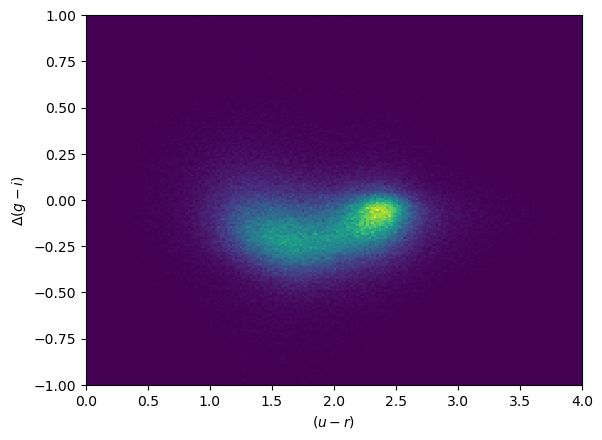

In [8]:
plt.hist2d(nsa_good_cd['NSA_u_r'], nsa_good_cd['NSA_cd'], 
           bins=200, 
           range=[[0,4], [-1, 1]], 
          )

plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ \Delta (g-i)$')

(-1.0, 1.0)

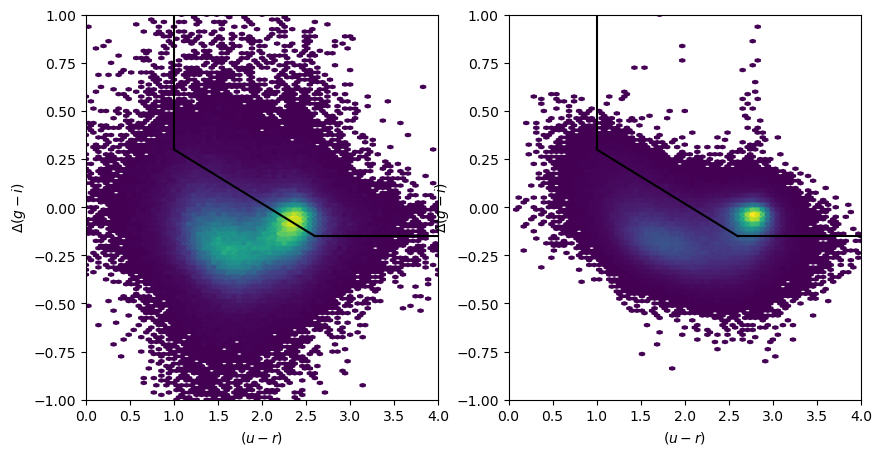

In [9]:
fig = plt.figure(figsize=(10,5))
# plt.add_subplot

fig.add_subplot(121)
plt.hexbin(nsa_good_cd['NSA_u_r'], nsa_good_cd['NSA_cd'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(0, 4, -1, 1), 
           zorder=2)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')
plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ \Delta (g-i)$')

plt.xlim(0,4)
plt.ylim(-1,1)

fig.add_subplot(122)
plt.hexbin(kias['u_r_KIAS'], kias['cd'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(0, 4, -1, 1), 
           zorder=2)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')
plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ \Delta (g-i)$')

plt.xlim(0,4)
plt.ylim(-1,1)

### $c_{\rm inv} \ \& \ (u-r)$

Text(0, 0.5, '$ c_{\\rm inv}$')

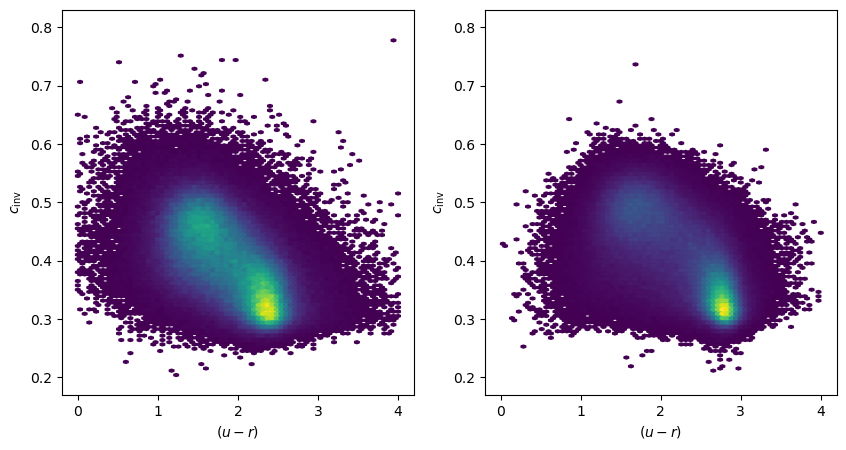

In [10]:
fig = plt.figure(figsize=(10,5))
# plt.add_subplot

fig.add_subplot(121)

plt.hexbin(nsa_good_cd['NSA_u_r'], nsa_good_cd['NSA_cinv'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(0, 4, 0.2, 0.8), 
           zorder=2)
plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ c_{\rm inv}$')
# plt.xlim(

fig.add_subplot(122)
plt.hexbin(kias['u_r_KIAS'], kias['conx1'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(0, 4, 0.2, 0.8), 
           zorder=2)

# plt.plot([4,2.6],[-0.15,-0.15], color='k')
# plt.plot([2.6,1.0],[-0.15,0.3], color='k')
# plt.plot([1.0,1.0],[0.3,10], color='k')
# plt.xlabel(r'$(u-r)$')
# plt.ylabel(r'$ \Delta (g-i)$')
# plt.hist2d(nsa_good_cd['NSA_u_r'], nsa_good_cd['NSA_cinv'], 
#            bins=200, 
#            range=[[0,4], [0, 1]], 
#           )

plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ c_{\rm inv}$')

### $\Delta (g-i) \ \& \ c_{\rm inv}$

Text(0, 0.5, '$ c_{\\rm inv}$')

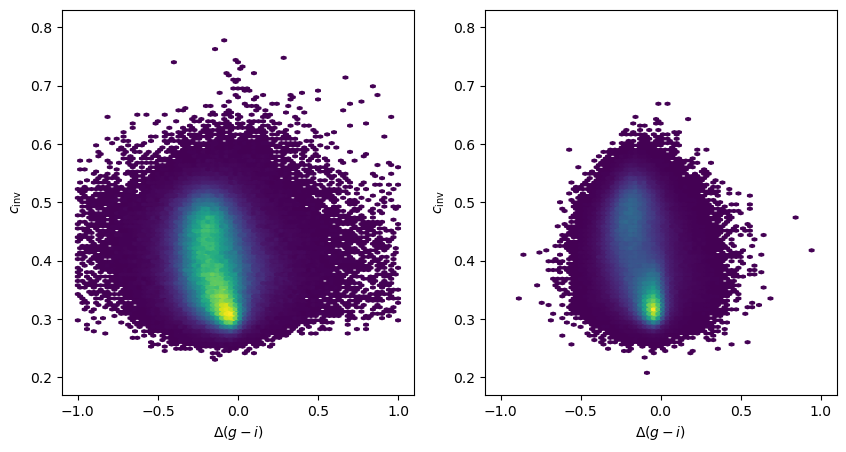

In [11]:
fig = plt.figure(figsize=(10,5))
# plt.add_subplot

fig.add_subplot(121)

plt.hexbin(nsa_good_cd['NSA_cd'], nsa_good_cd['NSA_cinv'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(-1, 1, 0.2, 0.8), 
           zorder=2)

# plt.hist2d(nsa_good_cd['NSA_cd'], nsa_good_cd['NSA_cinv'], 
#            bins=200, 
#            range=[[-1,1], [0, 1]], 
#           )

plt.xlabel(r'$\Delta (g-i)$')
plt.ylabel(r'$ c_{\rm inv}$')


fig.add_subplot(122)
plt.hexbin(kias['cd'], kias['conx1'], 
           # bins=200, 
           # range=[[0,4], [-1, 1]], 
          # cmap='plasma', 
           mincnt=2, 
           vmin=1, 
           # vmax=70, 
           gridsize=(70,80), 
           extent=(-1, 1, 0.2, 0.8), 
           zorder=2)

plt.xlabel(r'$\Delta (g-i)$')
plt.ylabel(r'$ c_{\rm inv}$')

### join kias and nsa tables

In [12]:
nsa_kias = join(nsa_good_cd, kias, keys='IAUNAME')

In [13]:
nsa_kias[:5]

IAUNAME,SUBDIR_1,RA_1,DEC_1,ISDSS_1,INED_1,ISIXDF_1,IALFALFA_1,IZCAT_1,ITWODF_1,MAG_1,Z_1,ZSRC_1,SIZE_1,RUN_1,CAMCOL_1,FIELD_1,RERUN_1,XPOS_1,YPOS_1,NSAID_1,ZDIST_1,SERSIC_NMGY_1,SERSIC_NMGY_IVAR_1,SERSIC_OK_1,SERSIC_RNMGY_1,SERSIC_ABSMAG_1,SERSIC_AMIVAR_1,EXTINCTION_1,SERSIC_KCORRECT_1,SERSIC_KCOEFF_1,SERSIC_MTOL_1,SERSIC_B300_1,SERSIC_B1000_1,SERSIC_METS_1,SERSIC_MASS_1,XCEN_1,YCEN_1,NPROF_1,PROFMEAN_1,PROFMEAN_IVAR_1,QSTOKES_1,USTOKES_1,BASTOKES_1,PHISTOKES_1,PETRO_FLUX_1,PETRO_FLUX_IVAR_1,FIBER_FLUX_1,FIBER_FLUX_IVAR_1,PETRO_BA50_1,PETRO_PHI50_1,PETRO_BA90_1,PETRO_PHI90_1,SERSIC_FLUX_1,SERSIC_FLUX_IVAR_1,SERSIC_N_1,SERSIC_BA_1,SERSIC_PHI_1,ASYMMETRY_1,CLUMPY_1,DFLAGS_1,AID_1,PID_1,DVERSION_1,PROFTHETA_1,PETRO_THETA_1,PETRO_TH50_1,PETRO_TH90_1,SERSIC_TH50_1,PLATE_1,FIBERID_1,MJD_1,RACAT_1,DECCAT_1,ZSDSSLINE_1,SURVEY_1,PROGRAMNAME_1,PLATEQUALITY_1,TILE_1,PLUG_RA_1,PLUG_DEC_1,ELPETRO_BA_1,ELPETRO_PHI_1,ELPETRO_FLUX_R_1,ELPETRO_FLUX_IVAR_R_1,ELPETRO_THETA_R_1,ELPETRO_TH50_R_1,ELPETRO_TH90_R_1,ELPETRO_THETA_1,ELPETRO_FLUX_1,ELPETRO_FLUX_IVAR_1,ELPETRO_TH50_1,ELPETRO_TH90_1,ELPETRO_APCORR_R_1,ELPETRO_APCORR_1,ELPETRO_APCORR_SELF_1,ELPETRO_NMGY_1,ELPETRO_NMGY_IVAR_1,ELPETRO_OK_1,ELPETRO_RNMGY_1,ELPETRO_ABSMAG_1,ELPETRO_AMIVAR_1,ELPETRO_KCORRECT_1,ELPETRO_KCOEFF_1,ELPETRO_MASS_1,ELPETRO_MTOL_1,ELPETRO_B300_1,ELPETRO_B1000_1,ELPETRO_METS_1,IN_DR7_LSS_1,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,NSA_u_r,NSA_NUV_r,NSA_cinv,SUBDIR_2,RA_2,DEC_2,ISDSS_2,INED_2,ISIXDF_2,IALFALFA_2,IZCAT_2,ITWODF_2,MAG_2,Z_2,ZSRC_2,SIZE_2,RUN_2,CAMCOL_2,FIELD_2,RERUN_2,XPOS_2,YPOS_2,NSAID_2,ZDIST_2,SERSIC_NMGY_2,SERSIC_NMGY_IVAR_2,SERSIC_OK_2,SERSIC_RNMGY_2,SERSIC_ABSMAG_2,SERSIC_AMIVAR_2,EXTINCTION_2,SERSIC_KCORRECT_2,SERSIC_KCOEFF_2,SERSIC_MTOL_2,SERSIC_B300_2,SERSIC_B1000_2,SERSIC_METS_2,SERSIC_MASS_2,XCEN_2,YCEN_2,NPROF_2,PROFMEAN_2,PROFMEAN_IVAR_2,QSTOKES_2,USTOKES_2,BASTOKES_2,PHISTOKES_2,PETRO_FLUX_2,PETRO_FLUX_IVAR_2,FIBER_FLUX_2,FIBER_FLUX_IVAR_2,PETRO_BA50_2,PETRO_PHI50_2,PETRO_BA90_2,PETRO_PHI90_2,SERSIC_FLUX_2,SERSIC_FLUX_IVAR_2,SERSIC_N_2,SERSIC_BA_2,SERSIC_PHI_2,ASYMMETRY_2,CLUMPY_2,DFLAGS_2,AID_2,PID_2,DVERSION_2,PROFTHETA_2,PETRO_THETA_2,PETRO_TH50_2,PETRO_TH90_2,SERSIC_TH50_2,PLATE_2,FIBERID_2,MJD_2,RACAT_2,DECCAT_2,ZSDSSLINE_2,SURVEY_2,PROGRAMNAME_2,PLATEQUALITY_2,TILE_2,PLUG_RA_2,PLUG_DEC_2,ELPETRO_BA_2,ELPETRO_PHI_2,ELPETRO_FLUX_R_2,ELPETRO_FLUX_IVAR_R_2,ELPETRO_THETA_R_2,ELPETRO_TH50_R_2,ELPETRO_TH90_R_2,ELPETRO_THETA_2,ELPETRO_FLUX_2,ELPETRO_FLUX_IVAR_2,ELPETRO_TH50_2,ELPETRO_TH90_2,ELPETRO_APCORR_R_2,ELPETRO_APCORR_2,ELPETRO_APCORR_SELF_2,ELPETRO_NMGY_2,ELPETRO_NMGY_IVAR_2,ELPETRO_OK_2,ELPETRO_RNMGY_2,ELPETRO_ABSMAG_2,ELPETRO_AMIVAR_2,ELPETRO_KCORRECT_2,ELPETRO_KCOEFF_2,ELPETRO_MASS_2,ELPETRO_MTOL_2,ELPETRO_B300_2,ELPETRO_B1000_2,ELPETRO_METS_2,IN_DR7_LSS_2,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],floa

In [14]:
len(nsa_kias)

467948

### calculate kias cmd

In [16]:
def cmd_class(u_r, cd, cinv):

    theta = np.degrees(np.arctan((-cd +0.3)/(u_r - 1))) + 90

    if u_r > 2.5 and cinv < 0.38 and cd > -0.28125*u_r +0.58125 and cd > -0.15:

        return 3

    elif (u_r < 2.5 and cd > -0.28125*u_r + 0.58125) or ((u_r < 1 or cd < -0.28125*u_r +0.58135) and cinv > 0.38) or ((u_r < 1 or cd < -0.28125*u_r +0.58135) and theta < 110):
        return 2

    elif (u_r < 1 or cd < -0.28125*u_r + 0.58125) and theta > 100:

        return 1

     

    else:
        return -999
        
    

In [21]:
nsa_kias['CMD_KIAS'] = np.ones(len(nsa_kias))*-999

for i in tqdm.tqdm(range(len(nsa_kias))):
    
    nsa_kias['CMD_KIAS'][i] = cmd_class(nsa_kias['u_r_KIAS'][i], nsa_kias['cd'][i], nsa_kias['conx1'][i])


/tmp/ipykernel_2057032/1260583048.py:3: RuntimeWarning: divide by zero encountered in double_scalars
  theta = np.degrees(np.arctan((-cd +0.3)/(u_r - 1))) + 90
100%|██████████| 467948/467948 [00:03<00:00, 121782.40it/s]


### plot cmd with KIAS classification

AttributeError: PathCollection.set() got an unexpected keyword argument 'size'

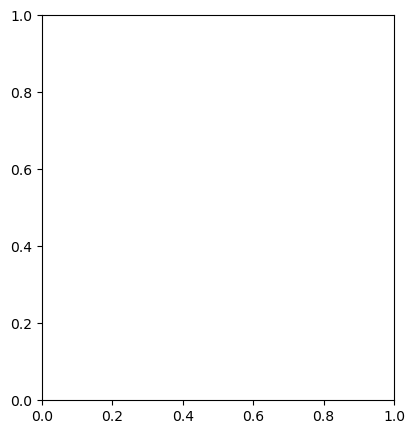

In [22]:
fig = plt.figure(figsize=(10,5))
# plt.add_subplot

fig.add_subplot(121)
plt.scatter(nsa_kias['NSA_u_r'][nsa_kias['CMD_KIAS'] == 3], nsa_kias['NSA_cd'][nsa_kias['CMD_KIAS'] == 3], c='r', marker='o', size=1)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')
plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ \Delta (g-i)$')

plt.xlim(0,4)
plt.ylim(-1,1)

fig.add_subplot(122)
plt.scatter(nsa_kias['u_r_KIAS'][nsa_kias['CMD_KIAS'] == 3], nsa_kias['cd'][nsa_kias['CMD_KIAS'] == 3], )
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')
plt.xlabel(r'$(u-r)$')
plt.ylabel(r'$ \Delta (g-i)$')

plt.xlim(0,4)
plt.ylim(-1,1)